In [4]:
pip install pandas matplotlib seaborn


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.9 MB 15.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 15.5 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.3 MB 16.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.2 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----------- ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
pip install openpyxl



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
#Load Excel file
df = pd.read_excel("Online Retail.xlsx")

# Inspect first 5 rows
# df.head()

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
df.shape

(541909, 8)

In [ ]:
# cleaning
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]




In [16]:
#dropping rows with no cust id
df = df.dropna(subset=['CustomerID'])

# Add TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
df.shape

(397924, 9)

In [20]:
# TOTAL REVENUE
total_revenue = df['TotalPrice'].sum()
print(f"Total revenue is: {total_revenue}")

Total revenue is: 8911407.904


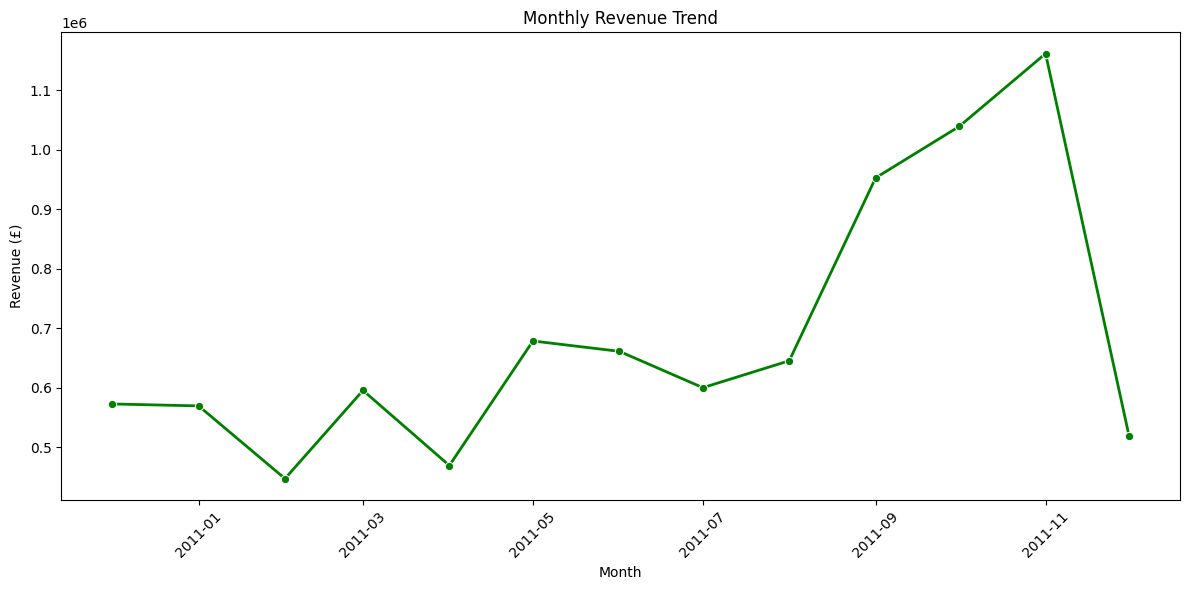

In [24]:
# monthly revenue
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Year-Month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

# Monthly Revenue
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue, x='YearMonth', y='TotalPrice', marker='o',color='green',linewidth=2)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

C:\Users\sanju\AppData\Local\Temp\ipykernel_16900\1790127457.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


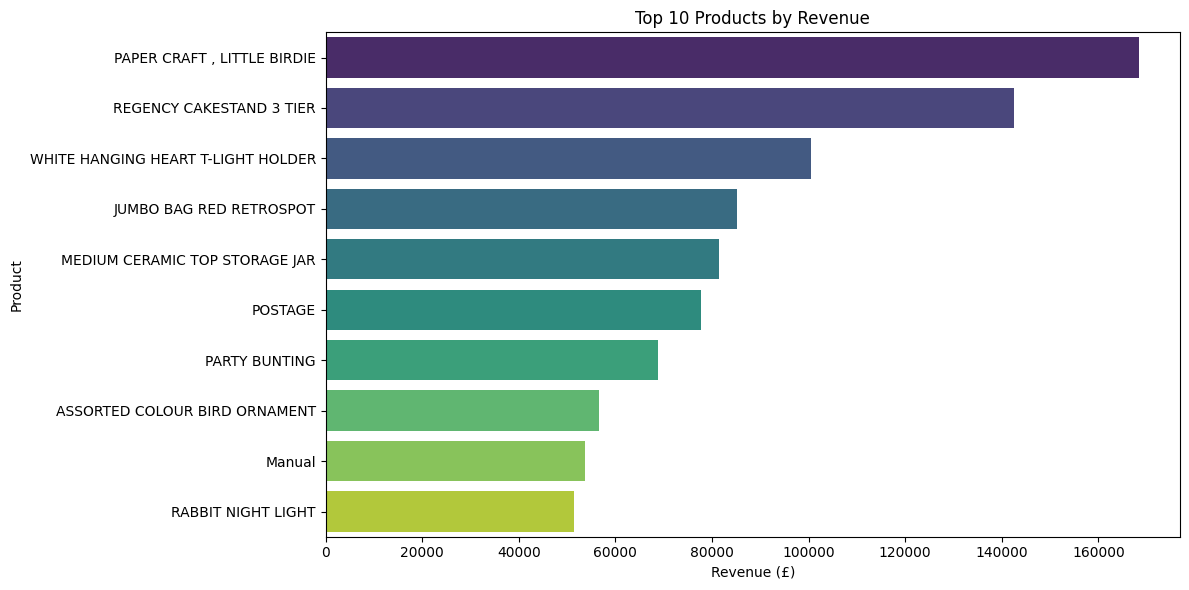

In [25]:
# top 10 products
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


C:\Users\sanju\AppData\Local\Temp\ipykernel_16900\3282537324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='magma')


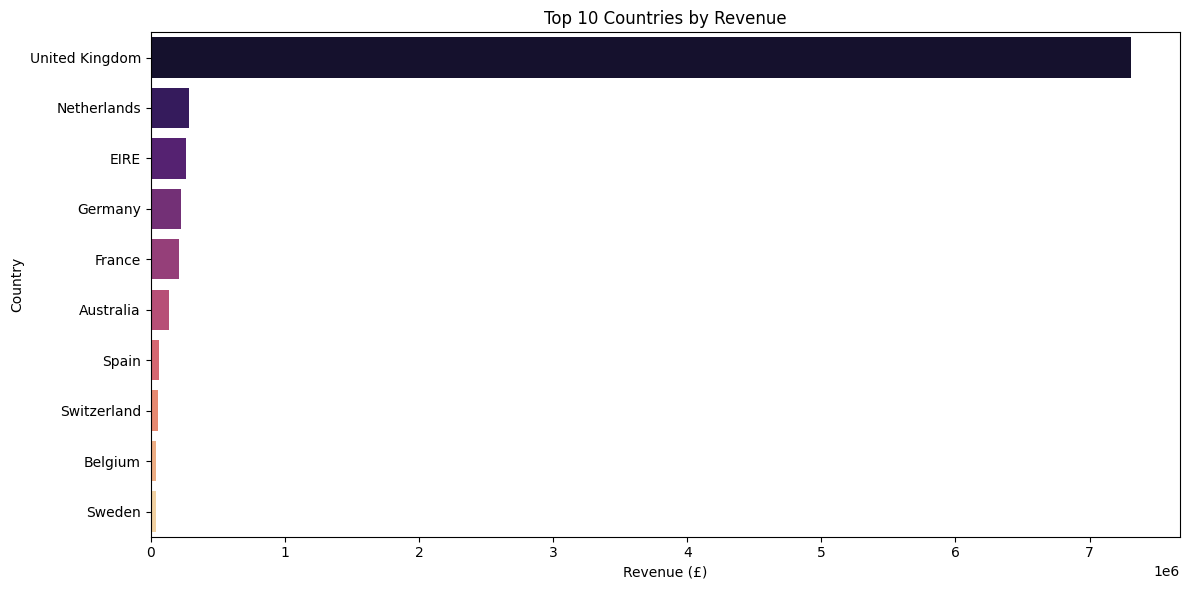

In [26]:
# top 10 country by revenue
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='magma')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [27]:
# RFM = RECENCY, FREQUENCY, MONETARY
# Set reference date as one day after last invoice
import datetime

today_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference Date for Recency:", today_date)

Reference Date for Recency: 2011-12-10 12:50:00


In [28]:
#calculatinf RFM VAL
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                               # Frequency
    'TotalPrice': 'sum'                                   # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Check
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


C:\Users\sanju\AppData\Local\Temp\ipykernel_16900\646991731.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Monetary', y='CustomerID', data=top_spenders, palette='viridis', ax=axes[0])
C:\Users\sanju\AppData\Local\Temp\ipykernel_16900\646991731.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='CustomerID', data=top_frequency, palette='magma', ax=axes[1])
C:\Users\sanju\AppData\Local\Temp\ipykernel_16900\646991731.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recency', y='CustomerID', data=recent_customer

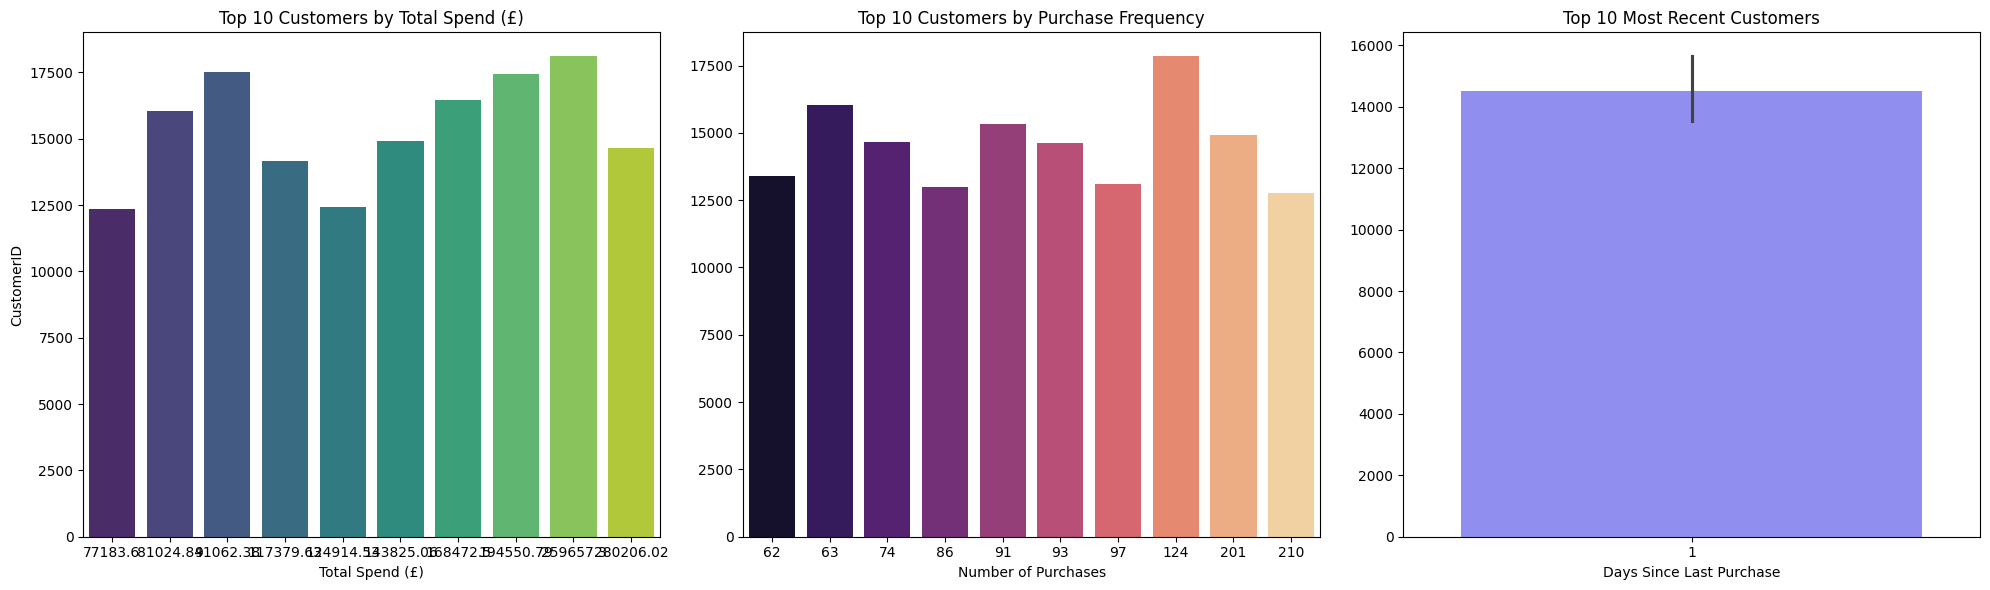

In [32]:
# Set up a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# 1️⃣ Top 10 Customers by Monetary
top_spenders = rfm.sort_values('Monetary', ascending=False).head(10)
sns.barplot(x='Monetary', y='CustomerID', data=top_spenders, palette='viridis', ax=axes[0])
axes[0].set_title("Top 10 Customers by Total Spend (£)")
axes[0].set_xlabel("Total Spend (£)")
axes[0].set_ylabel("CustomerID")

# 2️⃣ Top 10 Customers by Frequency
top_frequency = rfm.sort_values('Frequency', ascending=False).head(10)
sns.barplot(x='Frequency', y='CustomerID', data=top_frequency, palette='magma', ax=axes[1])
axes[1].set_title("Top 10 Customers by Purchase Frequency")
axes[1].set_xlabel("Number of Purchases")
axes[1].set_ylabel("")

# 3️⃣ Most Recent Customers
recent_customers = rfm.sort_values('Recency').head(10)
sns.barplot(x='Recency', y='CustomerID', data=recent_customers, palette='cool', ax=axes[2])
axes[2].set_title("Top 10 Most Recent Customers")
axes[2].set_xlabel("Days Since Last Purchase")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()